## Análisis Exploratorio

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Cargamos el dataset limpio
df = pd.read_csv('/Users/alberth/Documents/Proyectos/credit_risk/data/processed.csv')
df.riesgo = df.riesgo.map({0:'No', 1:'Si'})
df.head()

,id,edad,ingresos,genero,estado_civil,num_hijos,num_tarjetas,modalidad_pago,hipoteca,prestamos,riesgo
0,100756,46,59944,M,Casado,1,2,Mensual,Si,0,No
1,100668,67,59692,F,Casado,1,1,Mensual,Si,0,No
2,100418,50,59508,M,Casado,1,1,Mensual,Si,1,No
3,100416,24,59463,M,Casado,0,2,Mensual,Si,1,No
4,100590,34,59393,F,Casado,0,2,Mensual,Si,0,No


In [3]:
# Revisamos si existen valores faltantes
print('--- Valores faltantes ---')
df.isnull().sum()

--- Valores faltantes ---


id                0
edad              0
ingresos          0
genero            0
estado_civil      0
num_hijos         0
num_tarjetas      0
modalidad_pago    0
hipoteca          0
prestamos         0
riesgo            0
dtype: int64

In [4]:
# Revisamos si existen filas duplicadas
print(f'Número de registros duplicados: {df.duplicated('id').sum()}')

Número de registros duplicados: 0


Analizamos cada variable para obtener algunos insights, y calculamos pruebas de significancia estadística.

### Edad

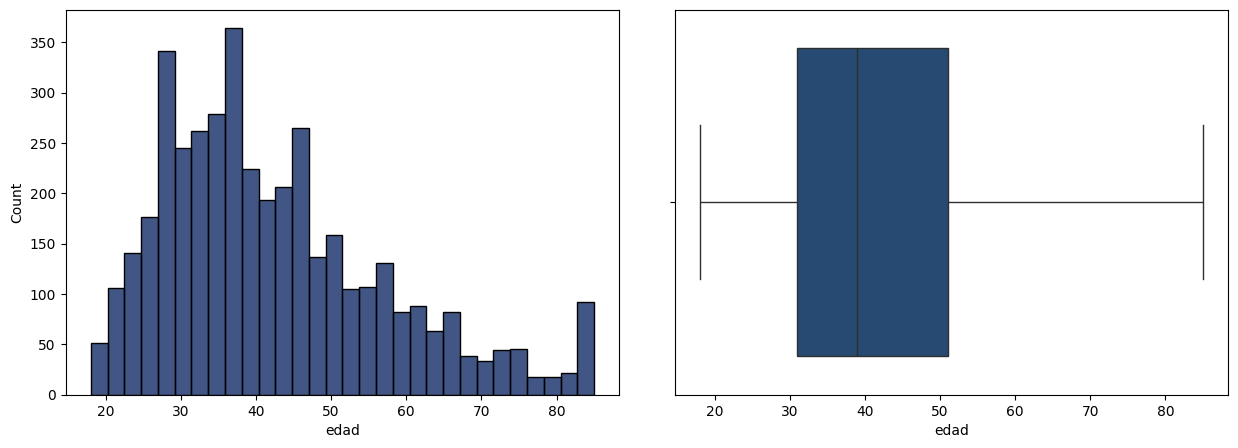

In [5]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x='edad', bins=30, color="#021E5C")
plt.subplot(1,2,2)
sns.boxplot(data=df, x='edad', whis=3, color="#1A497E")
plt.subplots_adjust(wspace=0.1)
plt.show()

Separamos según la variable riesgo

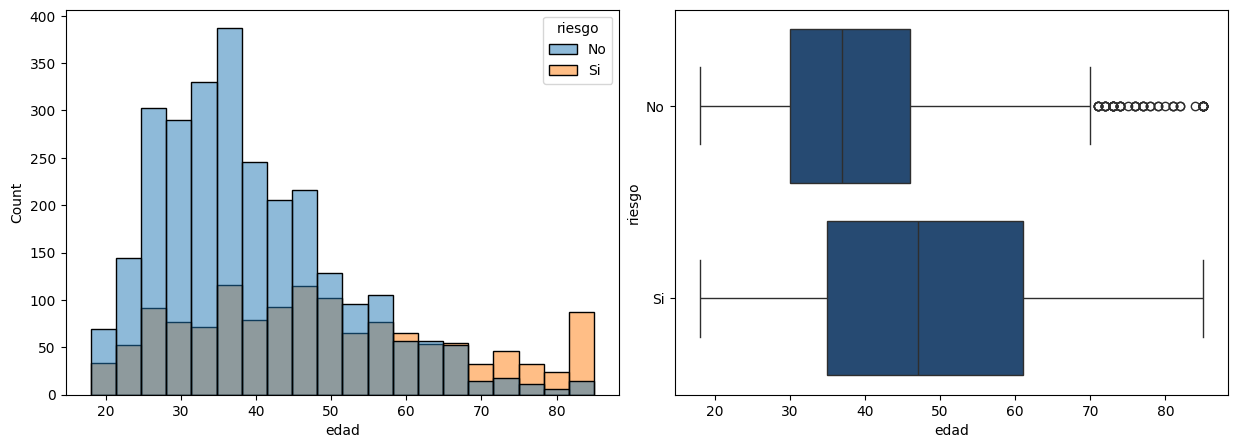

In [6]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x='edad', bins=20, hue='riesgo', hue_order=['No', 'Si'], alpha=0.5)
plt.subplot(1,2,2)
sns.boxplot(data=df, x='edad', color="#1A497E", y='riesgo')
plt.subplots_adjust(wspace=0.1)
plt.show()

In [7]:
df.groupby('riesgo')['edad'].agg(mean='mean',median='median',q25=lambda x: x.quantile(0.25),q75=lambda x: x.quantile(0.75)).round()

,mean,median,q25,q75
riesgo,,,,
No,39.0,37.0,30.0,46.0
Si,49.0,47.0,35.0,61.0


Se observa una tendencia en la edad de los clientes.

Especificamente, el grupo de clientes con riesgo de impago está compuesto en su mayoría por gente mayor, con un promedio de edad de 49 años y una mediana de 47. El 50% de este grupo lo conforman edades entre 35 y 61 años, a diferencia del grupo que no presenta riesgo cuyas edades tienden a ser un poco mas jovenes (el 50% de estos entre los 30 y los 46 años).

### Ingresos

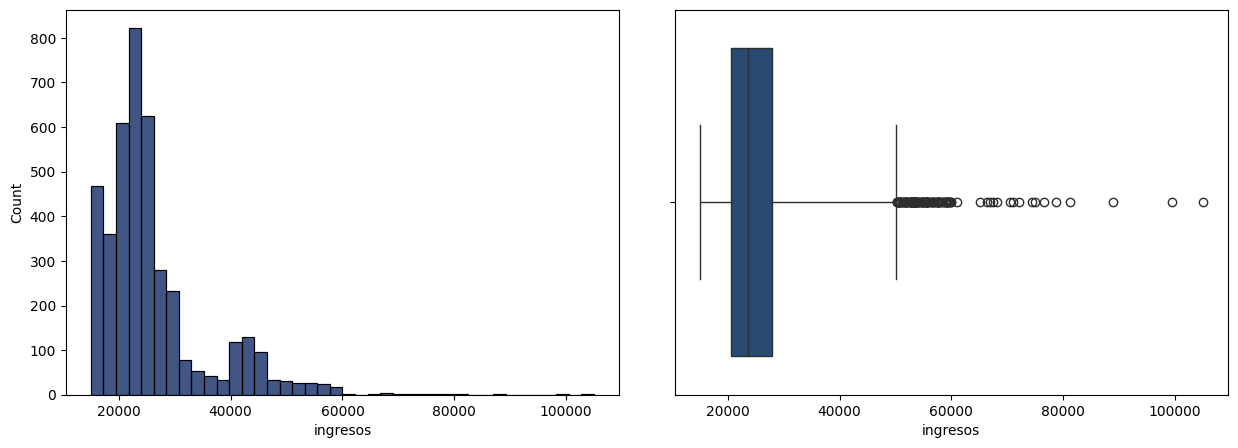

In [8]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x='ingresos', bins=40, color="#021E5C")
plt.subplot(1,2,2)
sns.boxplot(data=df, x='ingresos', whis=3, color="#1A497E")
plt.subplots_adjust(wspace=0.1)
plt.show()

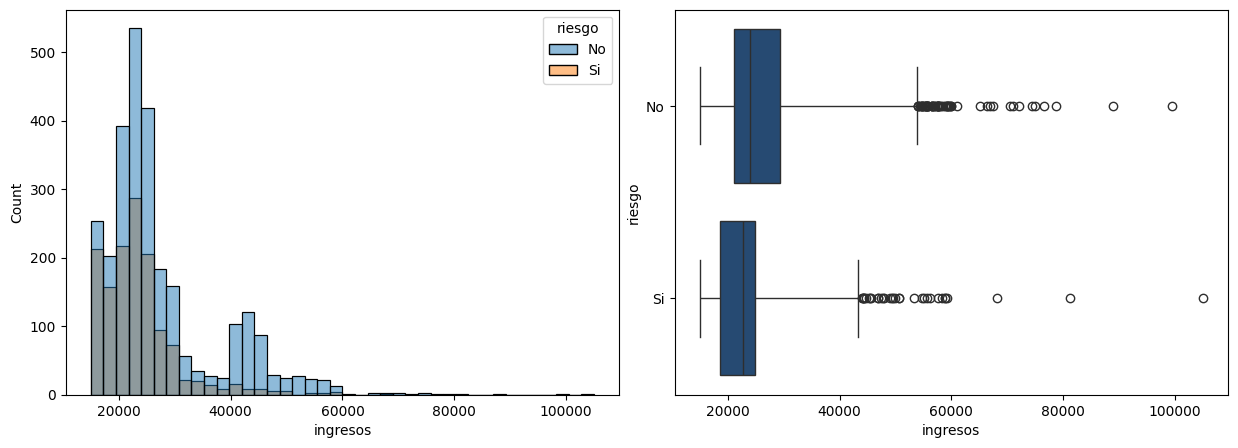

In [9]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(data=df, x='ingresos', bins=40, color="#021E5C", hue='riesgo', hue_order=['No', 'Si'])
plt.subplot(1,2,2)
sns.boxplot(data=df, x='ingresos', whis=3, color="#1A497E", y='riesgo')
plt.subplots_adjust(wspace=0.1)
plt.show()

In [10]:
df.groupby('riesgo')['ingresos'].agg(mean='mean',median='median',q25=lambda x: x.quantile(0.25),q75=lambda x: x.quantile(0.75)).round()

,mean,median,q25,q75
riesgo,,,,
No,27231.0,23978.0,21066.0,29265.0
Si,23546.0,22748.0,18702.0,24972.0


se observa que en el grupo de clientes con riesgo, estos se concentran en valores de ingresos ligeramente más bajos.

In [11]:
from scipy.stats import mannwhitneyu

ingresos_no = df[df.riesgo == 'No']['ingresos']
ingresos_si = df[df.riesgo == 'Si']['ingresos']

stat, p_valor = mannwhitneyu(ingresos_no, ingresos_si)
print(f"p-valor: {p_valor}")

p-valor: 4.5846890159776515e-28


Se rechaza la hipótesis nula, confirmando que la diferencia de ingresos entre ambos grupos (riesgo y no-riesgo) es estadísticamente significativa.

### Género

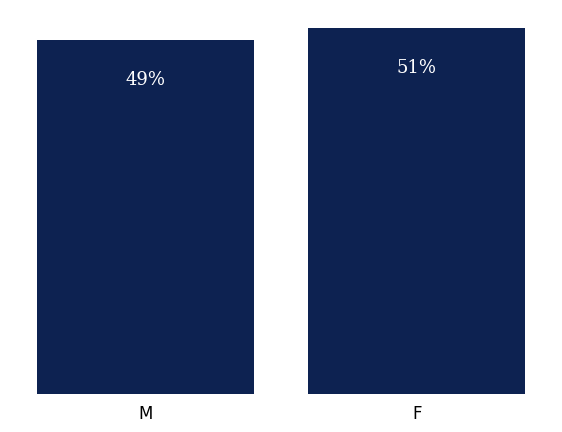

In [12]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='genero', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

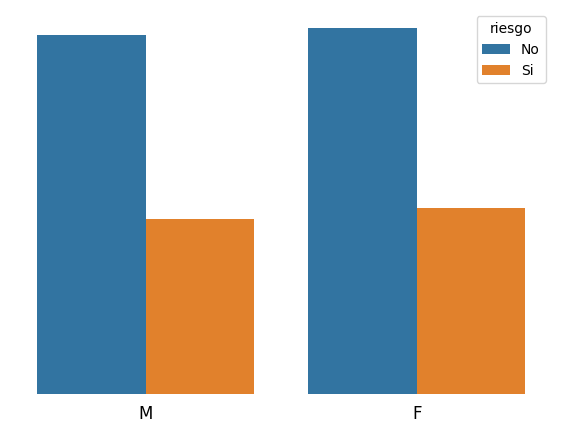

In [13]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='genero', hue='riesgo', hue_order=['No', 'Si'])

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

### Estado civil

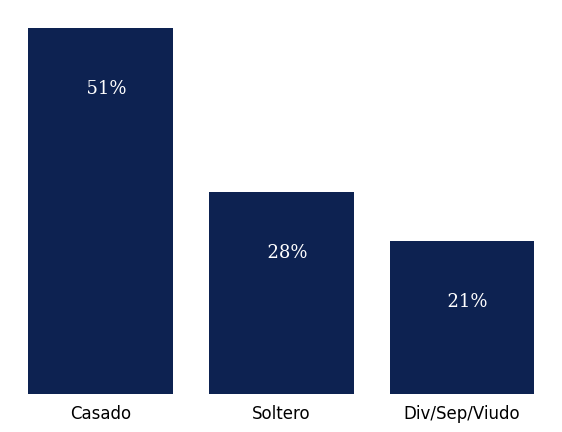

In [14]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='estado_civil', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"  {(p.get_height() / total) * 100:.0f}%" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

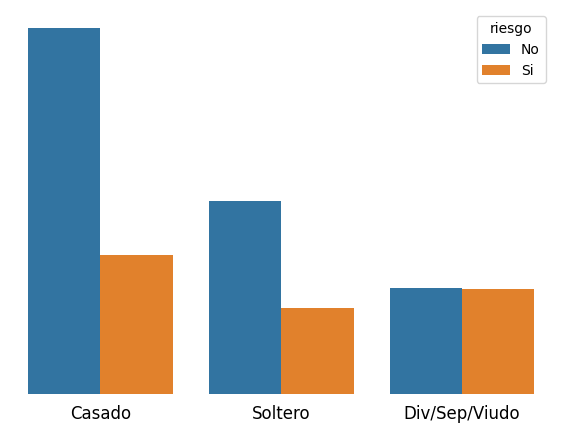

In [15]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='estado_civil', hue='riesgo', hue_order=['No', 'Si'])

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [16]:
pd.crosstab(index=df.estado_civil, columns=df.riesgo, normalize=0).round(2)

riesgo,No,Si
estado_civil,,
Casado,0.72,0.28
Div/Sep/Viudo,0.50,0.50
Soltero,0.69,0.31


Se observa que ser casado o soltero disminuye la probabilidad de riesgo en comparación al otro grupo (Divorciado/Separado/Viudo)

In [17]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df.num_hijos, df.riesgo)
chi2, p_valor, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p_valor}")

p-valor: 3.931681633533178e-42


Se recazha la hipótesis nula, confirmando que la variable estado civil es estadísticamente significativa.

### Número de hijos

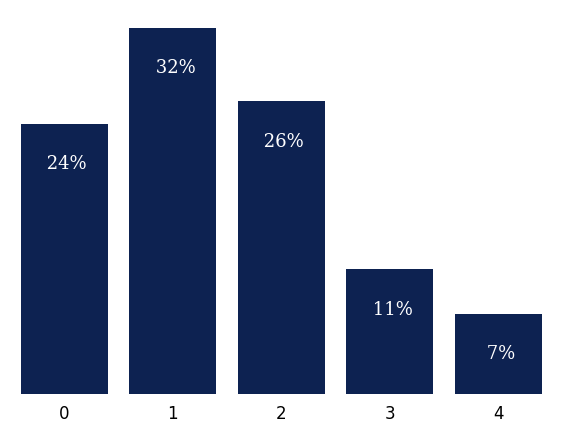

In [18]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='num_hijos', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f" {(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

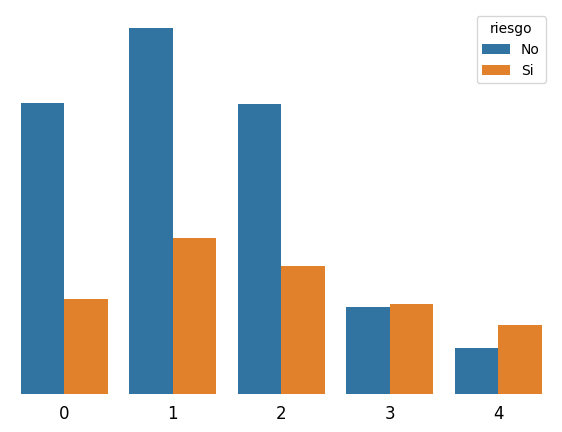

In [19]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='num_hijos', hue='riesgo', hue_order=['No', 'Si'])

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [20]:
pd.crosstab(index=df.num_hijos, columns=df.riesgo, normalize=0).round(2)

riesgo,No,Si
num_hijos,,
0,0.75,0.25
1,0.70,0.30
2,0.69,0.31
3,0.49,0.51
4,0.40,0.60


Se observa una tendencia clara respecto al número de hijos, y es que a medida que aumenta el número de hijos también aumenta la probabilidad de impago.

In [21]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df.num_hijos, df.riesgo)
chi2, p_valor, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p_valor}")

p-valor: 3.931681633533178e-42


Se rechaza la hipótesis nula, confirmando que el número de hijos está estadísticamente asociado al riesgo de impago.

### Número de tarjetas

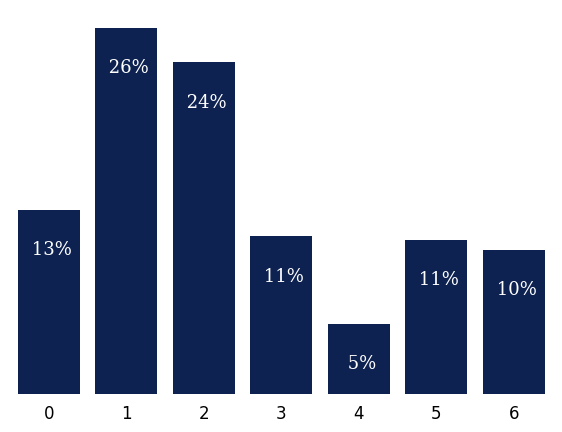

In [22]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='num_tarjetas', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f" {(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

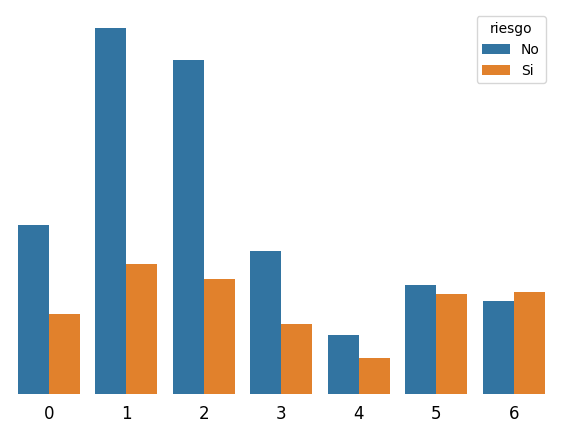

In [23]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='num_tarjetas', hue='riesgo', hue_order=['No', 'Si'])

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [24]:
pd.crosstab(index=df.num_tarjetas, columns=df.riesgo, normalize=0).round(2)

riesgo,No,Si
num_tarjetas,,
0,0.68,0.32
1,0.74,0.26
2,0.74,0.26
3,0.67,0.33
4,0.62,0.38
5,0.52,0.48
6,0.48,0.52


Se observa que los clientes que poseen entre 1 y 2 tarjetas presentan una tasa de impago significativamente menor en comparación a las demás categorías (0,3,4 y 5 tarjetas), incluso se observa que los los clientes con 6 tarjetas presentan una probabilidad de impago superior al 50%.

In [25]:
tabla = pd.crosstab(df.num_tarjetas, df.riesgo)
chi2, p_valor, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p_valor}")

p-valor: 8.769452776718512e-33


Se rechaza la hipótesis nula y se confirma que el número de tarjetas está estadísticamente asociado al riesgo de impago.

### Modalidad de pago

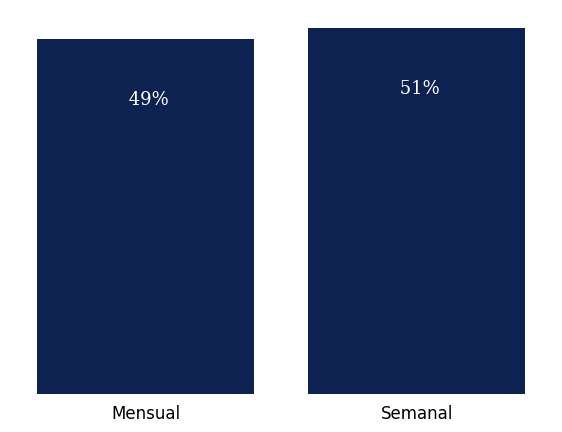

In [26]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='modalidad_pago', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f" {(p.get_height() / total) * 100:.0f}%" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

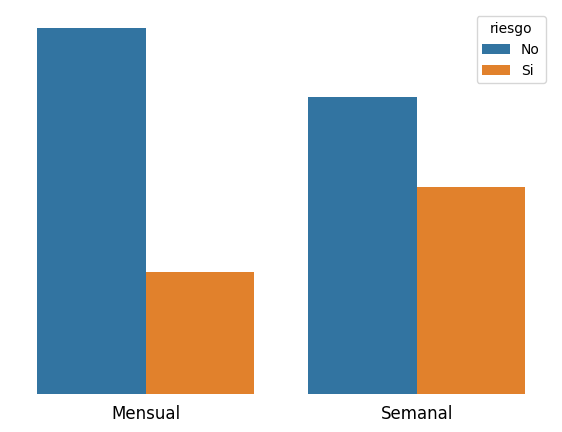

In [27]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='modalidad_pago', hue='riesgo', hue_order=['No', 'Si'])

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [28]:
pd.crosstab(index=df.modalidad_pago, columns=df.riesgo, normalize=0).round(2)

riesgo,No,Si
modalidad_pago,,
Mensual,0.75,0.25
Semanal,0.59,0.41


Se evidencia que los clientes con modalidad de pago semanal presentan una mayor probabilidad de impago en comparación a los que pagan mensualmente.

In [29]:
tabla = pd.crosstab(df.modalidad_pago, df.riesgo)
chi2, p_valor, dof, expected = chi2_contingency(tabla)
print(f"p-valor: {p_valor}")

p-valor: 1.1482723543949619e-27


Se rechaza la hipótesis nula, confirmando que la modalidad de pago está estadísticamente asociada al riesgo de impago.

### Hipoteca

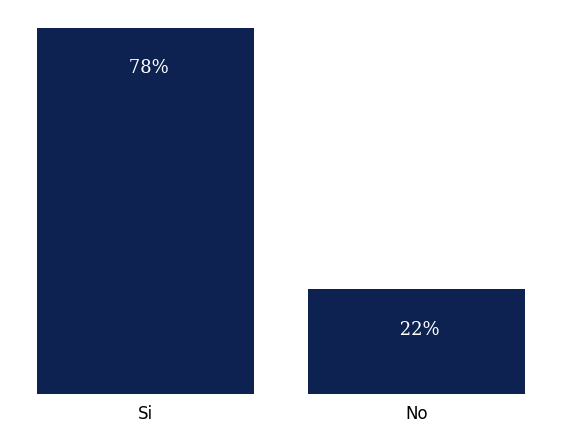

In [30]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='hipoteca', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f" {(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

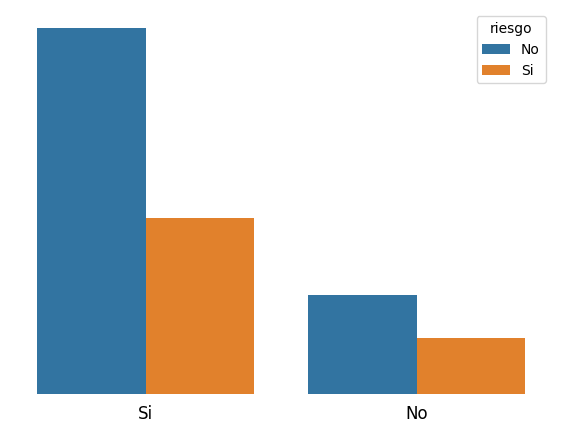

In [31]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='hipoteca', hue='riesgo', hue_order=['No', 'Si'])

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [32]:
pd.crosstab(index=df.hipoteca, columns=df.riesgo, normalize=0).round(2)

riesgo,No,Si
hipoteca,,
No,0.64,0.36
Si,0.68,0.32


### Número de prestamos

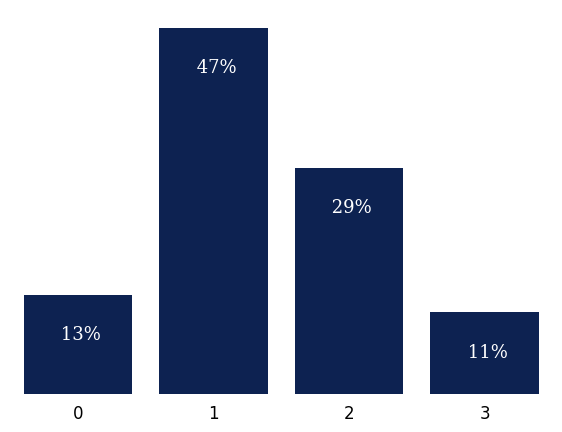

In [33]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='prestamos', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f" {(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

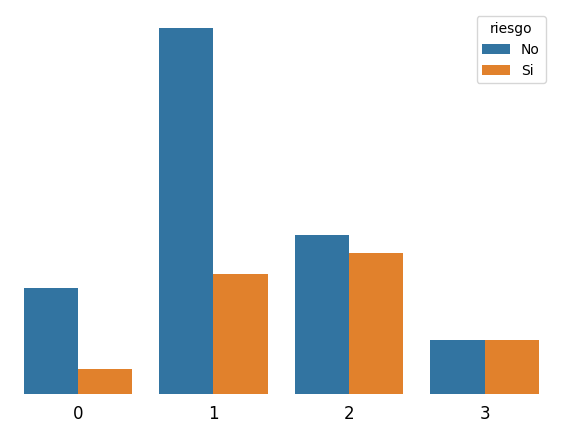

In [34]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='prestamos', hue='riesgo', hue_order=['No', 'Si'])

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f"{(p.get_height() / total) * 100:.0f}%\n" for p in ax.patches]

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

In [35]:
pd.crosstab(index=df.prestamos, columns=df.riesgo, normalize=0).round(2)

riesgo,No,Si
prestamos,,
0,0.80,0.20
1,0.75,0.25
2,0.53,0.47
3,0.50,0.50


Se observa que a medida que aumenta el número de prestamos también aumenta la probabilidad de impago.

In [36]:
tabla = pd.crosstab(df.prestamos, df.riesgo)
chi2, p_valor, dof, expected = chi2_contingency(tabla)

print(f"p-valor: {p_valor}")

p-valor: 3.963557028982237e-58


Se rechaza la hipótesis nula, confirmando que el número de prestamos está estadísticamente asociado al riesgo de impago.

### Riesgo

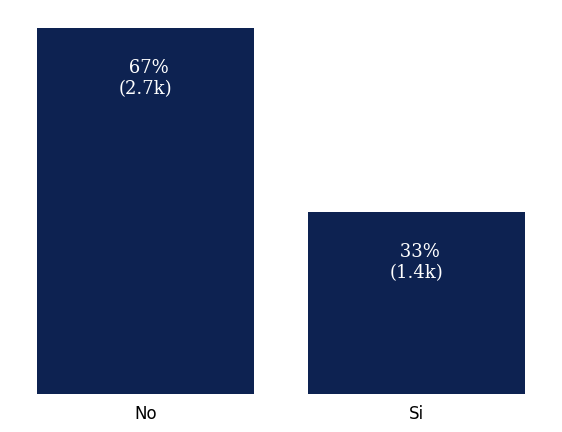

In [37]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='riesgo', color="#021E5C")

ax.set_yticks([])
ax.tick_params(bottom=False, labelsize=12)
sns.despine(left=True, bottom=True)

total = len(df)
etiquetas = [f" {(p.get_height() / total) * 100:.0f}%\n({p.get_height() / 1000:.1f}k)" for p in ax.patches]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=-50, color='white', fontproperties={'family': 'serif', 'size': 13, 'weight': 300})

ax.set_xlabel('')
ax.set_ylabel('')
plt.show()

Se evidencia un significativo desbalance de clases, el cual debe ser tenido en cuenta en la etapa de entrenamiento de los modelos.